In [1]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import seaborn as ans
import matplotlib.pyplot as plt

In [2]:
iris=load_iris()

In [3]:
X=iris.data
y=iris.target

In [4]:
X_scaled=StandardScaler().fit_transform(X)

In [6]:
X.shape

(150, 4)

In [10]:
#Apply PCA and Visualize scree plot


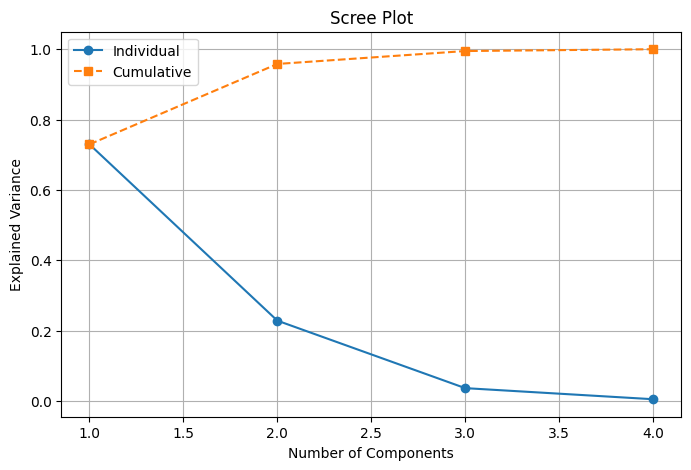

In [9]:
pca=PCA()
X_pca=pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, 'o-', label='Individual')
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), 's--',label='Cumulative')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('Scree Plot')
plt.grid(True)
plt.legend()
plt.show()

In [11]:
#choose number of components(95% variance)

In [12]:
pca_95=PCA(n_components=0.95)
X_reduced=pca_95.fit_transform(X_scaled)
print(f"Reduced Shape{X_reduced.shape}")

Reduced Shape(150, 2)


In [13]:
#visualize top 2 components

In [14]:
import seaborn as sns

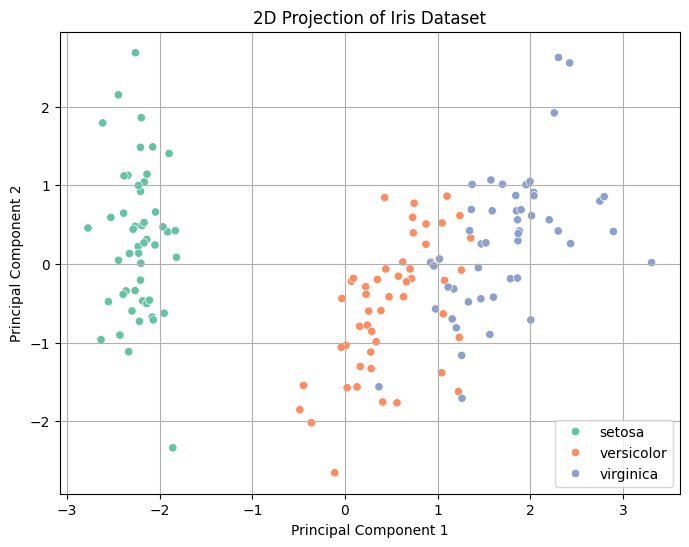

In [15]:
pca_2d=PCA(n_components=2)
X_2d=pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_2d[:,0],y=X_2d[:,1],hue=iris.target_names[y],palette='Set2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D Projection of Iris Dataset')
plt.grid(True)
plt.show()

In [22]:
df=pd.read_csv(r"C:\Users\gurra\HierarchicalClustering\marketing_campaign.csv",sep="\t")

In [24]:
features = [
    'Income','Recency','NumWebPurchases','NumCatalogPurchases',
    'NumStorePurchases','NumWebVisitsMonth',
    'MntWines','MntFruits','MntMeatProducts','MntFishProducts',
    'MntSweetProducts','MntGoldProds'
]

In [25]:
X = df[features]

In [26]:
X = X.fillna(X.mean())

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
print("Shape:", X_scaled.shape)

Shape: (2240, 12)


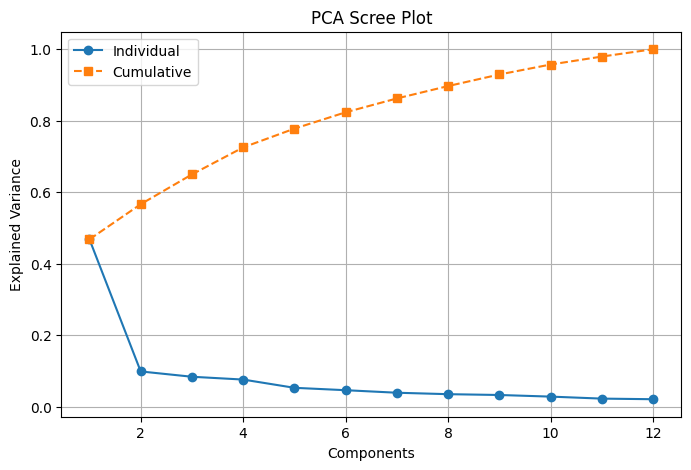

In [29]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.plot(range(1,len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_,'o-',label='Individual')

plt.plot(range(1,len(pca.explained_variance_ratio_)+1),
         np.cumsum(pca.explained_variance_ratio_),'s--',
         label='Cumulative')

plt.xlabel("Components")
plt.ylabel("Explained Variance")
plt.title("PCA Scree Plot")
plt.legend()
plt.grid()
plt.show()

In [30]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cum_var >= 0.90) + 1

print("Components needed for 90% variance:", n_components)


Components needed for 90% variance: 9


In [31]:
pca_final = PCA(n_components=n_components)
X_reduced = pca_final.fit_transform(X_scaled)


In [32]:
loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=[f"PC{i+1}" for i in range(n_components)],
    index=features
)

print(loadings[['PC1','PC2']].sort_values(by='PC1',ascending=False))


                          PC1       PC2
NumCatalogPurchases  0.345198 -0.051202
MntMeatProducts      0.338193 -0.204507
MntWines             0.316788  0.326735
Income               0.316305 -0.036874
NumStorePurchases    0.315459  0.222367
MntFishProducts      0.310689 -0.198573
MntFruits            0.301485 -0.179426
MntSweetProducts     0.300540 -0.145944
MntGoldProds         0.247503  0.253692
NumWebPurchases      0.235184  0.637931
Recency              0.007319 -0.089029
NumWebVisitsMonth   -0.268660  0.475213


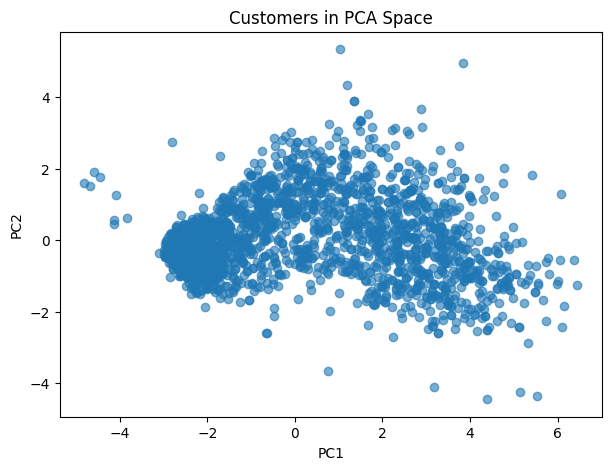

In [33]:
pca_2 = PCA(n_components=2)
X_2d = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0],X_2d[:,1],alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customers in PCA Space")
plt.show()


In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time

k = 4

# Original
start = time.time()
kmeans_orig = KMeans(n_clusters=k,random_state=42)
labels_orig = kmeans_orig.fit_predict(X_scaled)
t1 = time.time()-start
sil_orig = silhouette_score(X_scaled,labels_orig)

# PCA
start = time.time()
kmeans_pca = KMeans(n_clusters=k,random_state=42)
labels_pca = kmeans_pca.fit_predict(X_reduced)
t2 = time.time()-start
sil_pca = silhouette_score(X_reduced,labels_pca)

print("Original Silhouette:",sil_orig)
print("PCA Silhouette:",sil_pca)
print("Original Time:",t1)
print("PCA Time:",t2)


Original Silhouette: 0.2704711537719226
PCA Silhouette: 0.2789649433526844
Original Time: 0.21575140953063965
PCA Time: 0.004930019378662109


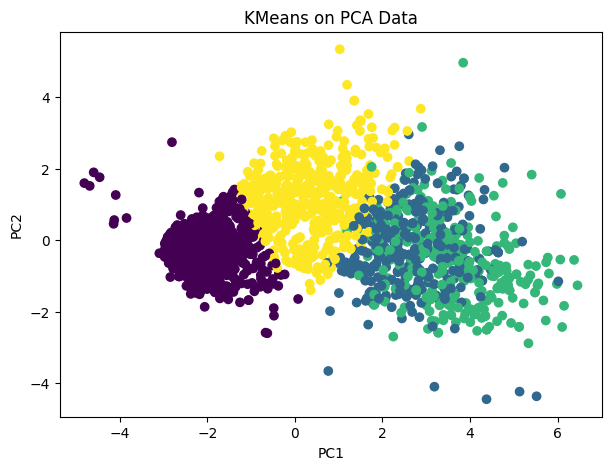

In [35]:
plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0],X_2d[:,1],c=labels_pca)
plt.title("KMeans on PCA Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
